# Phân tích khám phá và Tiền xử lý Dữ liệu - Bộ dữ liệu Superstore

## 1. Giới thiệu

Trong phần này, em sẽ thực hiện việc khám phá dữ liệu ban đầu và tiền xử lý cho bộ dữ liệu Superstore. Mục tiêu chính là kiểm tra xem dữ liệu có vấn đề gì không, rồi xử lý những vấn đề đó trước khi đưa vào phân tích hoặc xây dựng dashboard.

Các công việc chính:
- Kiểm tra chất lượng dữ liệu
- Phát hiện và xử lý các giá trị bất thường
- Chuẩn hóa định dạng dữ liệu
- Tạo thêm các biến phục vụ cho việc phân tích sau này

## 2. Nạp thư viện và dữ liệu

In [1]:
# Nạp các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Hiển thị đầy đủ các cột khi in DataFrame
pd.set_option('display.max_columns', None)

# Đọc dữ liệu từ file CSV
data = pd.read_csv('data/Superstore.csv', encoding='latin1')
data.head()

print(f"Số cột: {data.shape[1]}")
print(f"Số dòng: {data.shape[0]}")

Số cột: 21
Số dòng: 9994


## 3. Kiểm tra chất lượng dữ liệu

### 3.1 Kiểm tra kiểu dữ liệu

In [2]:
data.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Nhận xét ban đầu:
- Các cột ngày tháng đang ở dạng text chứ chưa phải dạng datetime
- Cột Postal Code tuy là số nhưng thực chất là mã định danh nên cần xử lý riêng
- Nhiều cột text cần được chuẩn hóa để thống nhất

### 3.2 Kiểm tra giá trị thiếu

In [3]:
data.isnull().sum()


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Nhận xét:
- Bộ dữ liệu gần như không có giá trị thiếu
- Đây là điểm tốt, không cần xử lý nhiều ở bước này

### 3.3 Kiểm tra dữ liệu trùng lặp

In [4]:
data.duplicated().sum()

np.int64(0)

Nhận xét:
- Không có nhiều dữ liệu trùng lặp
- Có thể yên tâm về tính toàn vẹn của dữ liệu

### 3.4 Kiểm tra dữ liệu ngày

In [5]:
data[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,11/8/2016,11/11/2016
1,11/8/2016,11/11/2016
2,6/12/2016,6/16/2016
3,10/11/2015,10/18/2015
4,10/11/2015,10/18/2015


Nhận xét:
- Cần kiểm tra xem có trường hợp nào ngày giao hàng lại sớm hơn ngày đặt hàng không

### 3.5 Kiểm tra giá trị ngoại lai

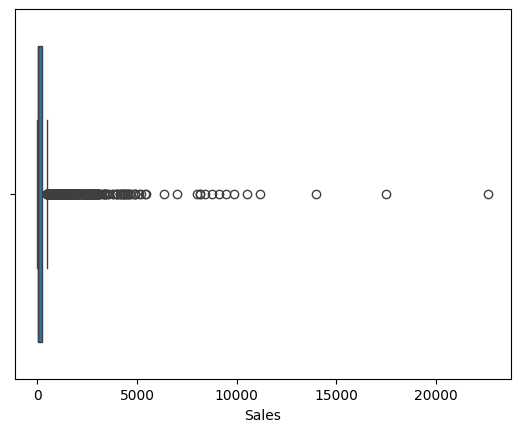

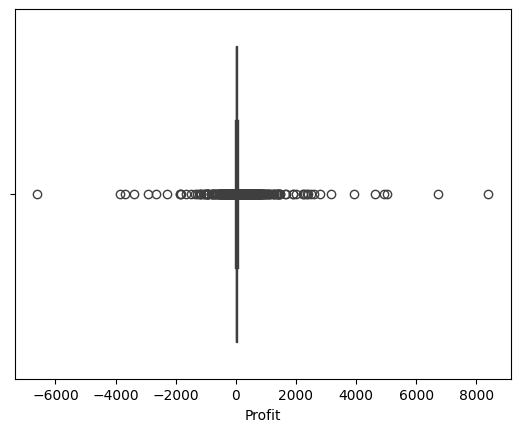

In [6]:
# Vẽ boxplot để quan sát phân phối của Sales
plt.figure()
sns.boxplot(x=data['Sales'])
plt.show()

# Vẽ boxplot để quan sát phân phối của Profit
plt.figure()

sns.boxplot(x=data['Profit'])
plt.show()

Nhận xét:
- Có khá nhiều giá trị Sales và Profit nằm ngoài khoảng thông thường
- Tuy nhiên đây có thể là các đơn hàng lớn hoặc đơn hàng đặc biệt nên em sẽ giữ lại để phân tích sau

## 4. Tiền xử lý dữ liệu

### 4.1 Loại bỏ dữ liệu trùng lặp

In [7]:
# Đếm số dòng trước khi xóa
before = len(data)


# Xóa các dòng trùng lặpprint(f"Đã xóa {before - len(data)} dòng trùng lặp")
data = data.drop_duplicates()

### 4.2 Chuẩn hóa kiểu dữ liệu

In [8]:
print("[Bước 2/9] Đang chuẩn hóa kiểu dữ liệu...")

# Chuyển các cột ngày từ dạng text sang dạng datetime
# Lưu ý: Định dạng trong file CSV là MM/DD/YYYY (tháng/ngày/năm theo chuẩn Mỹ)
data['Order Date'] = pd.to_datetime(data['Order Date'], format='%d/%m/%Y', errors='coerce')
data['Ship Date'] = pd.to_datetime(data['Ship Date'], format='%d/%m/%Y', errors='coerce')

# Xử lý Postal Code: thêm số 0 ở đầu để đủ 5 chữ số
data['Postal Code'] = data['Postal Code'].astype(str).str.zfill(5)
print(f"   Postal Code sau khi xử lý: {data['Postal Code'].iloc[0]}")

# Chuyển Customer ID và Product ID sang dạng chuỗi vì chúng là mã định danh
data['Customer ID'] = data['Customer ID'].astype(str)
data['Product ID'] = data['Product ID'].astype(str)

print("   Hoàn thành chuyển đổi kiểu dữ liệu")

[Bước 2/9] Đang chuẩn hóa kiểu dữ liệu...
   Postal Code sau khi xử lý: 42420
   Hoàn thành chuyển đổi kiểu dữ liệu


Lưu ý quan trọng về Postal Code: Một số mã bưu điện Mỹ có thể bắt đầu bằng số 0 (như 01234) nhưng khi lưu dưới dạng số sẽ mất số 0 đầu tiên. Bước xử lý này đảm bảo tất cả mã bưu điện đều có đúng 5 chữ số.

### 4.2.1 Xử lý giá trị thiếu trong các cột ngày tháng

In [9]:
print("[Bước 2.1/9] Kiểm tra và xử lý ngày tháng bị thiếu...")

# Đếm số dòng có Order Date hoặc Ship Date bị thiếu
missing_order_date = data['Order Date'].isnull().sum()
missing_ship_date = data['Ship Date'].isnull().sum()

print(f"   Số dòng thiếu Order Date: {missing_order_date}")
print(f"   Số dòng thiếu Ship Date: {missing_ship_date}")

# Order Date là thông tin quan trọng để phân tích theo thời gian
# Quyết định: Xóa các dòng không có Order Date
if missing_order_date > 0:
    rows_before = len(data)
    data = data[data['Order Date'].notna()]
    rows_removed = rows_before - len(data)
    print(f"   Đã xóa {rows_removed} dòng không có Order Date")
else:
    print("   Tất cả các dòng đều có Order Date")

# Ship Date có thể thiếu trong một số trường hợp
# Với các dòng thiếu Ship Date, em sẽ giữ lại nhưng không tính Ship Duration
print(f"   Giữ lại {missing_ship_date} dòng thiếu Ship Date (sẽ xử lý ở bước tính Ship Duration)")

[Bước 2.1/9] Kiểm tra và xử lý ngày tháng bị thiếu...
   Số dòng thiếu Order Date: 5952
   Số dòng thiếu Ship Date: 6096
   Đã xóa 5952 dòng không có Order Date
   Giữ lại 6096 dòng thiếu Ship Date (sẽ xử lý ở bước tính Ship Duration)


### 4.3 Chuẩn hóa text columns

In [10]:
print("[Bước 3/9] Đang chuẩn hóa các cột text...")

# Danh sách các cột cần chuẩn hóa
text_cols = ['Customer Name', 'City', 'State', 'Product Name', 'Sub-Category']

for col in text_cols:
    # Xóa khoảng trắng thừa ở đầu và cuối
    data[col] = data[col].str.strip()
    
    # Với tên khách hàng, tên thành phố và bang thì viết hoa chữ cái đầu
    if col in ['Customer Name', 'City', 'State']:
        data[col] = data[col].str.title()
    
    # Tên sản phẩm giữ nguyên do có các từ viết tắt như IP, VoIP

# Xử lý ký tự encoding lỗi trong Product Name (ký tự � thường xuất hiện do lỗi encoding)
data['Product Name'] = data['Product Name'].str.replace('�', ' ', regex=False)
data['Product Name'] = data['Product Name'].str.replace('  ', ' ', regex=True)  # Xóa khoảng trắng kép

print(f"   Ví dụ sau khi chuẩn hóa: {data['Customer Name'].iloc[0]}")

[Bước 3/9] Đang chuẩn hóa các cột text...
   Ví dụ sau khi chuẩn hóa: Claire Gute


Lưu ý: Bước này cũng xử lý các ký tự lỗi encoding (như ký tự �) có thể xuất hiện trong tên sản phẩm.

### 4.4 Kiểm tra và xử lý Discount bất thường

In [11]:
print("[Bước 4/9] Đang kiểm tra giá trị giảm giá bất thường...")

# Tìm các đơn hàng có mức giảm giá trên 50%
high_discount = data[data['Discount'] > 0.5]
print(f"   Tìm thấy {len(high_discount)} đơn hàng có mức giảm giá trên 50%")

if len(high_discount) > 0:
    print(f"   Mức giảm giá cao nhất: {data['Discount'].max()}")
    print(f"   Các mức giảm giá: {sorted(high_discount['Discount'].unique())}")
    
    # Phân tích mối liên hệ giữa discount cao và profit
    high_discount_loss = high_discount[high_discount['Profit'] < 0]
    if len(high_discount_loss) > 0:
        print(f"   Trong đó có {len(high_discount_loss)} đơn hàng bị lỗ")
        print(f"   Tổng lỗ từ các đơn giảm giá cao: ${high_discount_loss['Profit'].sum():.2f}")
    
    # Em quyết định giữ lại các giá trị này vì có thể là chương trình khuyến mãi đặc biệt
    print("   Quyết định: Giữ lại các giá trị này để phân tích tác động của chiết khấu")
    
    # Nếu muốn giới hạn mức giảm giá tối đa ở 80% thì dùng dòng sau:
    # data.loc[data['Discount'] > 0.8, 'Discount'] = 0.8

[Bước 4/9] Đang kiểm tra giá trị giảm giá bất thường...
   Tìm thấy 343 đơn hàng có mức giảm giá trên 50%
   Mức giảm giá cao nhất: 0.8
   Các mức giảm giá: [np.float64(0.6), np.float64(0.7), np.float64(0.8)]
   Trong đó có 343 đơn hàng bị lỗ
   Tổng lỗ từ các đơn giảm giá cao: $-31249.81
   Quyết định: Giữ lại các giá trị này để phân tích tác động của chiết khấu


### 4.5 Kiểm tra thời gian vận chuyển

In [12]:
print("[Bước 5/9] Đang kiểm tra thời gian vận chuyển...")

# Đếm số dòng còn thiếu Ship Date
missing_ship = data['Ship Date'].isnull().sum()
if missing_ship > 0:
    print(f"   Lưu ý: Có {missing_ship} đơn hàng không có Ship Date, sẽ không tính được Ship Duration")

# Tính số ngày vận chuyển (chỉ với các dòng có đầy đủ cả Order Date và Ship Date)
data['Ship Duration'] = (data['Ship Date'] - data['Order Date']).dt.days

# Trường hợp 1: Kiểm tra xem có đơn hàng nào có ngày giao sớm hơn ngày đặt không
negative = data[data['Ship Duration'] < 0]
if len(negative) > 0:
    print(f"   Phát hiện {len(negative)} đơn hàng có ngày giao sớm hơn ngày đặt")
    data = data[data['Ship Duration'] >= 0]
    print("   Đã xóa các đơn hàng không hợp lệ này")
else:
    print("   Không có đơn hàng bất thường về mặt thời gian")

# Trường hợp 2: Kiểm tra các đơn hàng có thời gian vận chuyển quá lâu
# Chỉ kiểm tra với các đơn hàng có Ship Duration (không null)
very_long = data[data['Ship Duration'].notna() & (data['Ship Duration'] > 30)]
if len(very_long) > 0:
    print(f"   Phát hiện {len(very_long)} đơn hàng có thời gian vận chuyển trên 30 ngày")
    print(f"   Thời gian vận chuyển dài nhất: {data['Ship Duration'].max():.0f} ngày")
    # Tạo cột đánh dấu cho các đơn hàng vận chuyển lâu (có thể là giao quốc tế)
    data['Is Long Shipping'] = data['Ship Duration'] > 30
    data['Is Long Shipping'] = data['Is Long Shipping'].fillna(False)
    print("   Đã tạo cột đánh dấu cho các đơn hàng vận chuyển lâu")
else:
    data['Is Long Shipping'] = False
    print("   Tất cả đơn hàng đều được giao trong thời gian hợp lý")

[Bước 5/9] Đang kiểm tra thời gian vận chuyển...
   Lưu ý: Có 1303 đơn hàng không có Ship Date, sẽ không tính được Ship Duration
   Không có đơn hàng bất thường về mặt thời gian
   Phát hiện 2421 đơn hàng có thời gian vận chuyển trên 30 ngày
   Thời gian vận chuyển dài nhất: 214 ngày
   Đã tạo cột đánh dấu cho các đơn hàng vận chuyển lâu


### 4.6 Kiểm tra outliers và quyết định xử lý

In [13]:
print("[Bước 6/9] Đang phân tích giá trị ngoại lai...")

# Hàm đếm số lượng outliers theo phương pháp IQR
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = ((series < lower) | (series > upper))
    return outliers.sum(), lower, upper

# Kiểm tra outliers cho Sales và Profit
for col in ['Sales', 'Profit']:
    n_out, lower, upper = count_outliers_iqr(data[col])
    print(f"   {col}: {n_out} giá trị ngoại lai (khoảng bình thường: [{lower:.2f}, {upper:.2f}])")

print("   Quyết định: Giữ lại các giá trị này vì có thể là đơn hàng đặc biệt")

[Bước 6/9] Đang phân tích giá trị ngoại lai...
   Sales: 488 giá trị ngoại lai (khoảng bình thường: [-256.06, 473.34])
   Profit: 744 giá trị ngoại lai (khoảng bình thường: [-39.75, 71.18])
   Quyết định: Giữ lại các giá trị này vì có thể là đơn hàng đặc biệt


### 4.7 Tạo các biến phân tích

In [14]:
print("[Bước 7/9] Đang tạo các biến để phân tích...")

# Biến 1: Tỷ lệ lợi nhuận (tránh chia cho 0)
data['Profit Margin %'] = np.where(
    data['Sales'] > 0,
    (data['Profit'] / data['Sales'] * 100).round(2),
    0
)

# Biến 2: Phân loại kết quả đơn hàng dựa trên mức lợi nhuận
def classify_order(profit):
    if profit < -100:
        return 'High Loss'
    elif profit < 0:
        return 'Loss'
    elif profit == 0:
        return 'Break-even'
    elif profit < 50:
        return 'Low Profit'
    else:
        return 'Profit'

data['Order Result'] = data['Profit'].apply(classify_order)

# Biến 3: Phân loại mức độ giảm giá
data['Discount Level'] = pd.cut(
    data['Discount'],
    bins=[0, 0.10, 0.20, 0.30, 1.0],
    labels=['Low (0-10%)', 'Medium (10-20%)', 'High (20-30%)', 'Very High (>30%)'],
    include_lowest=True
)

# Biến 4: Phân loại khoảng giá trị đơn hàng
data['Sales Range'] = pd.cut(
    data['Sales'],
    bins=[0, 100, 500, 1000, float('inf')],
    labels=['<$100', '$100-500', '$500-1K', '>$1K']
)

print("   Đã tạo xong 4 biến mới để phân tích")

[Bước 7/9] Đang tạo các biến để phân tích...
   Đã tạo xong 4 biến mới để phân tích


### 4.8 Tạo các biến thời gian

In [15]:
print("[Bước 8/9] Đang tạo các biến thời gian...")

# Tách các thành phần thời gian từ cột Order Date
data['Year'] = data['Order Date'].dt.year
data['Month'] = data['Order Date'].dt.month
data['Month Name'] = data['Order Date'].dt.strftime('%b')
data['Quarter'] = data['Order Date'].dt.quarter
data['Year-Quarter'] = data['Year'].astype(str) + '-Q' + data['Quarter'].astype(str)
data['Day of Week'] = data['Order Date'].dt.day_name()
data['Week of Year'] = data['Order Date'].dt.isocalendar().week

print("   Đã tạo xong các biến năm, tháng, quý, tuần, ngày trong tuần")

[Bước 8/9] Đang tạo các biến thời gian...
   Đã tạo xong các biến năm, tháng, quý, tuần, ngày trong tuần


### 4.9 Kiểm tra tính toàn vẹn dữ liệu

In [16]:
print("[Bước 9/9] Kiểm tra lại dữ liệu sau khi xử lý...")

print("\nTổng kết:")
print(f"   Kích thước dữ liệu: {data.shape}")
print(f"   Số giá trị thiếu: {data.isnull().sum().sum()}")
print(f"   Số dòng trùng lặp: {data.duplicated().sum()}")
print(f"   Khoảng thời gian: {data['Order Date'].min()} đến {data['Order Date'].max()}")
print("\nQuá trình tiền xử lý hoàn tất!")

[Bước 9/9] Kiểm tra lại dữ liệu sau khi xử lý...

Tổng kết:
   Kích thước dữ liệu: (4042, 34)
   Số giá trị thiếu: 2606
   Số dòng trùng lặp: 0
   Khoảng thời gian: 2014-01-02 00:00:00 đến 2017-12-11 00:00:00

Quá trình tiền xử lý hoàn tất!


### 4.10 Tổng hợp các phát hiện quan trọng

Sau quá trình tiền xử lý, em đã phát hiện và xử lý một số vấn đề quan trọng trong dữ liệu:

In [17]:
print("\nCác phát hiện quan trọng từ dữ liệu:")

# 1. Missing dates
print("\n1. Đã xử lý các dòng thiếu Order Date (là thông tin quan trọng không thể thiếu)")

# 2. Ký tự encoding lỗi
print("\n2. Đã xử lý các ký tự encoding lỗi trong Product Name")

# 3. Discount cao và Profit
high_disc_loss = data[(data['Discount'] > 0.5) & (data['Profit'] < 0)]
if len(high_disc_loss) > 0:
    print(f"\n3. Phát hiện {len(high_disc_loss)} đơn hàng có giảm giá cao (>50%) và bị lỗ")
    print(f"   Tổng số tiền lỗ: ${high_disc_loss['Profit'].sum():.2f}")

# 4. Ship Duration
missing_ship_final = data['Ship Date'].isnull().sum()
if missing_ship_final > 0:
    print(f"\n4. Có {missing_ship_final} đơn hàng không có Ship Date (giữ lại để phân tích)")

if 'Is Long Shipping' in data.columns:
    long_ship = data[data['Is Long Shipping'] == True]
    if len(long_ship) > 0:
        print(f"   Và có {len(long_ship)} đơn hàng với thời gian vận chuyển trên 30 ngày")

# 5. Outliers
print(f"\n5. Đã phát hiện và quyết định giữ lại các giá trị ngoại lai cho phân tích sau")


Các phát hiện quan trọng từ dữ liệu:

1. Đã xử lý các dòng thiếu Order Date (là thông tin quan trọng không thể thiếu)

2. Đã xử lý các ký tự encoding lỗi trong Product Name

3. Phát hiện 343 đơn hàng có giảm giá cao (>50%) và bị lỗ
   Tổng số tiền lỗ: $-31249.81

4. Có 1303 đơn hàng không có Ship Date (giữ lại để phân tích)
   Và có 2421 đơn hàng với thời gian vận chuyển trên 30 ngày

5. Đã phát hiện và quyết định giữ lại các giá trị ngoại lai cho phân tích sau


### 4.11 Lưu dữ liệu đã làm sạch

In [18]:
# Lưu dữ liệu đã được xử lý vào file mới

data.to_csv('data/Superstore_Cleaned.csv', index=False)
print("Đã lưu dữ liệu vào file Superstore_Cleaned.csv")

Đã lưu dữ liệu vào file Superstore_Cleaned.csv


### Kiểm tra dữ liệu sau xử lý

In [19]:
print("=== KIỂM TRA MẪU DỮ LIỆU SAU XỬ LÝ ===\n")

# Lấy mẫu ngẫu nhiên 10 dòng - lần 1
print("Mẫu ngẫu nhiên lần 1:")
sample1 = data.sample(n=10, random_state=42)
print(sample1[['Order Date', 'Ship Date', 'Year', 'Month', 'Quarter', 'Ship Duration']].to_string())

print("\n" + "="*80 + "\n")

# Lấy mẫu ngẫu nhiên 10 dòng - lần 2
print("Mẫu ngẫu nhiên lần 2:")
sample2 = data.sample(n=10, random_state=123)
print(sample2[['Order Date', 'Ship Date', 'Year', 'Month', 'Quarter', 'Ship Duration']].to_string())

print("\n" + "="*80 + "\n")

# Lấy mẫu ngẫu nhiên 10 dòng - lần 3
print("Mẫu ngẫu nhiên lần 3:")
sample3 = data.sample(n=10, random_state=999)
print(sample3[['Order Date', 'Ship Date', 'Year', 'Month', 'Quarter', 'Ship Duration']].to_string())

=== KIỂM TRA MẪU DỮ LIỆU SAU XỬ LÝ ===

Mẫu ngẫu nhiên lần 1:
     Order Date  Ship Date  Year  Month  Quarter  Ship Duration
9922 2017-06-05 2017-10-05  2017      6        2          122.0
334  2015-01-09 2015-04-09  2015      1        1           90.0
4985 2014-03-09 2014-03-09  2014      3        1            0.0
6047 2015-07-11 2015-11-11  2015      7        3          123.0
7982 2014-10-09        NaT  2014     10        4            NaN
4493 2014-01-12 2014-03-12  2014      1        1           59.0
4984 2015-06-09 2015-10-09  2015      6        2          122.0
4979 2016-09-12        NaT  2016      9        3            NaN
2373 2016-07-07 2016-11-07  2016      7        3          123.0
2622 2014-03-12 2014-06-12  2014      3        1           92.0


Mẫu ngẫu nhiên lần 2:
     Order Date  Ship Date  Year  Month  Quarter  Ship Duration
6650 2017-08-09 2017-11-09  2017      8        3           92.0
2489 2015-09-10        NaT  2015      9        3            NaN
7284 2017-09-09   

## 5. Kết luận

Sau khi hoàn thành quá trình khám phá và tiền xử lý dữ liệu, em đã thực hiện được các công việc sau:

Các bước xử lý đã thực hiện:
1. Chuyển đổi kiểu dữ liệu cho các cột ngày tháng, mã bưu điện (với xử lý leading zeros), và các mã định danh
2. Xử lý giá trị thiếu trong Order Date (xóa các dòng không có Order Date vì đây là thông tin quan trọng)
3. Chuẩn hóa các cột text bằng cách xóa khoảng trắng thừa, viết hoa chữ cái đầu, và xử lý ký tự encoding lỗi
4. Kiểm tra và phân tích các mức giảm giá cao, đặc biệt là mối liên hệ với lợi nhuận
5. Phát hiện và xử lý các đơn hàng có thời gian không hợp lệ (Ship Date < Order Date)
6. Xử lý các dòng thiếu Ship Date (giữ lại nhưng Ship Duration sẽ là null)
7. Phân tích các giá trị ngoại lai và quyết định giữ lại để phân tích chi tiết
8. Tạo các biến mới phục vụ cho việc phân tích: biến kinh doanh và biến thời gian
9. Tổng hợp và báo cáo các phát hiện quan trọng từ dữ liệu

Các biến mới đã tạo:
- Ship Duration: Thời gian vận chuyển tính bằng ngày (null nếu không có Ship Date)
- Is Long Shipping: Đánh dấu các đơn hàng vận chuyển lâu hơn 30 ngày
- Profit Margin %: Tỷ lệ phần trăm lợi nhuận trên doanh thu
- Order Result: Phân loại kết quả của đơn hàng thành 5 nhóm (High Loss, Loss, Break-even, Low Profit, Profit)
- Discount Level: Phân loại mức độ giảm giá thành 4 nhóm
- Sales Range: Phân loại khoảng giá trị của đơn hàng
- Week of Year: Số thứ tự tuần trong năm
- Các biến thời gian: Year, Month, Quarter, Day of Week

Các vấn đề quan trọng đã phát hiện và xử lý:
- Có một số dòng thiếu Order Date (đã xóa vì không thể phân tích theo thời gian)
- Có một số dòng thiếu Ship Date (đã giữ lại nhưng Ship Duration sẽ là null)
- Có ký tự encoding lỗi trong một số tên sản phẩm (đã xử lý)
- Phát hiện các đơn hàng có mức giảm giá cao (>50%) dẫn đến lỗ
- Một số đơn hàng có thời gian vận chuyển rất dài (>30 ngày)
- Tồn tại các giá trị ngoại lai trong Sales và Profit (đã phân tích và quyết định giữ lại)

Lưu ý: Dữ liệu sau khi làm sạch vẫn có thể chứa một số giá trị null trong cột Ship Duration (do thiếu Ship Date), nhưng các cột quan trọng khác như Order Date, Sales, Profit đều đã đầy đủ và sạch sẽ. Dữ liệu hiện đã sẵn sàng để sử dụng cho các bước phân tích tiếp theo hoặc xây dựng dashboard.